# Time Series Analysis & Forecasting of India's UPI Transactions

**Goal:** Analyze monthly UPI transaction volume in India and forecast future transaction volume.

**Primary target:** `UPI_Transactions_Mn` — monthly transaction volume in millions.

**Secondary variable:** `UPI_Value_Cr` — monthly transaction value in ₹ crore.

**Official source:** NPCI UPI Product Statistics.



In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Load the NPCI data

In [ ]:
df = pd.read_csv("/content/Combined_UPI_Product_Statistics_Chronological.csv")

print(df)
print("Shape:", df.shape)
display(df.head())
display(df.tail())

             Month  No. of Banks live on UPI  Volume (In Mn.)  Value (In Cr.)
0       April-2016                        21             0.00            0.00
1         May-2016                        21             0.00            0.00
2        June-2016                        21             0.00            0.00
3        July-2016                        21             0.09            0.38
4      August-2016                        21             0.09            3.09
..             ...                       ...              ...             ...
115  November-2025                       684        20,466.98    2,631,632.63
116  December-2025                       685        21,634.67    2,796,712.73
117   January-2026                       691        21,703.44    2,833,481.22
118  February-2026                       694        20,394.18    2,684,229.29
119     March-2026                       705        22,641.11    2,952,542.05

[120 rows x 4 columns]
Shape: (120, 4)


,Month,No. of Banks live on UPI,Volume (In Mn.),Value (In Cr.)
0,April-2016,21,0.00,0.00
1,May-2016,21,0.00,0.00
2,June-2016,21,0.00,0.00
3,July-2016,21,0.09,0.38
4,August-2016,21,0.09,3.09


,Month,No. of Banks live on UPI,Volume (In Mn.),Value (In Cr.)
115,November-2025,684,"20,466.98","2,631,632.63"
116,December-2025,685,"21,634.67","2,796,712.73"
117,January-2026,691,"21,703.44","2,833,481.22"
118,February-2026,694,"20,394.18","2,684,229.29"
119,March-2026,705,"22,641.11","2,952,542.05"


In [ ]:
df = df.rename(columns={
    "Month" : "Date",
    "No. of Banks live on UPI": "Banks_Live",
    "Volume (In Mn.)": "UPI_Transactions_Mn",
    "Value (In Cr.)": "UPI_Value_Cr"
})

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

for col in ["UPI_Transactions_Mn", "UPI_Value_Cr"]:
    df[col] = (
        df[col].astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("₹", "", regex=False)
        .str.strip()
        .replace({"": np.nan, "-": np.nan})
        .astype(float)
    )

df = (
    df.sort_values("Date")
      .drop_duplicates("Date")
      .set_index("Date")
)

display(df.head())

print(df.dtypes)

,Banks_Live,UPI_Transactions_Mn,UPI_Value_Cr
Date,,,
2016-04-01,21,0.00,0.00
2016-05-01,21,0.00,0.00
2016-06-01,21,0.00,0.00
2016-07-01,21,0.09,0.38
2016-08-01,21,0.09,3.09


Banks_Live               int64
UPI_Transactions_Mn    float64
UPI_Value_Cr           float64
dtype: object


In [ ]:
df.tail()

,Banks_Live,UPI_Transactions_Mn,UPI_Value_Cr
Date,,,
2025-11-01,684,"20,466.98","2,631,632.63"
2025-12-01,685,"21,634.67","2,796,712.73"
2026-01-01,691,"21,703.44","2,833,481.22"
2026-02-01,694,"20,394.18","2,684,229.29"
2026-03-01,705,"22,641.11","2,952,542.05"


## 3. Data-quality checks

In [ ]:
print("Start:", df.index.min())
print("End:", df.index.max())
print("Observations:", len(df))

print("\nMissing values:")
display(df.isna().sum())

print("Duplicate dates:", df.index.duplicated().sum())

print("\nCommon date gaps:")
display(df.index.to_series().diff().dropna().value_counts().head(10))

Start: 2016-04-01 00:00:00
End: 2026-03-01 00:00:00
Observations: 120

Missing values:


,0
Banks_Live,0
UPI_Transactions_Mn,0
UPI_Value_Cr,0


Duplicate dates: 0

Common date gaps:


,count
Date,
31 days,69
30 days,40
28 days,8
29 days,2


In [ ]:
# Enforce monthly-start frequency.
# If missing months appear, inspect the source instead of blindly filling them.

df = df.asfreq("MS")

print("Observations:", len(df))
print("\nMissing values after frequency check:")
display(df.isna().sum())

Observations: 120

Missing values after frequency check:


,0
Banks_Live,0
UPI_Transactions_Mn,0
UPI_Value_Cr,0


**Important:** Do not automatically forward-fill a missing UPI month. A forward-filled transaction count would be an invented observation. Check the NPCI source and correct the CSV if a month is missing.

## 4. Descriptive statistics

In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Banks_Live,120.00,296.88,225.20,21.00,126.50,218.00,495.25,705.00
UPI_Transactions_Mn,120.00,"6,079.21","6,890.97",0.00,463.24,"2,590.32","10,748.34","22,641.11"
UPI_Value_Cr,120.00,"892,022.31","926,685.19",0.00,"71,192.54","492,151.17","1,613,291.97","2,952,542.05"


## 5. Plot monthly UPI transaction volume


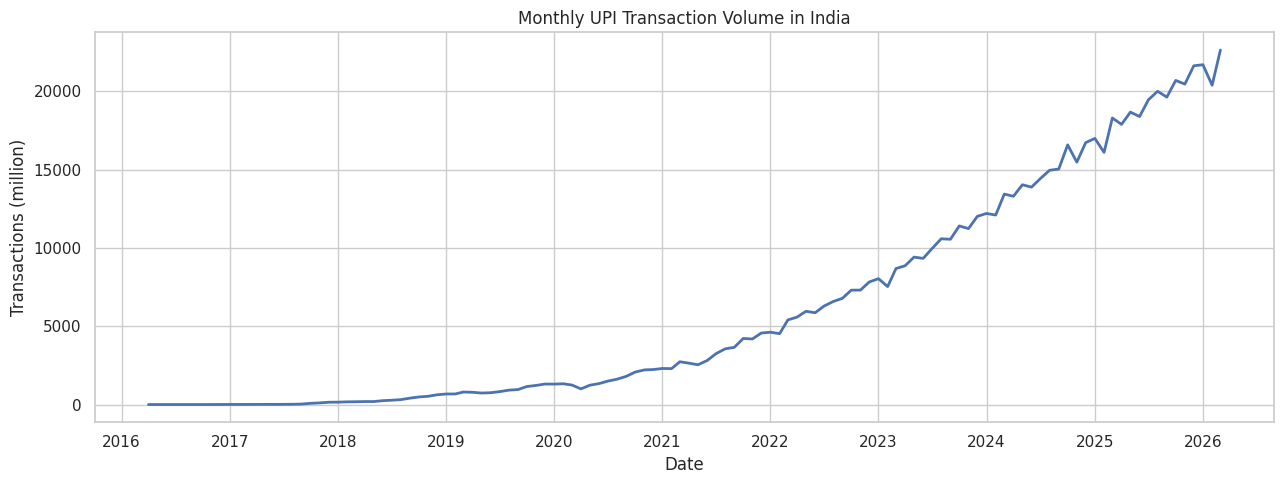

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df["UPI_Transactions_Mn"], linewidth=2)
ax.set_title("Monthly UPI Transaction Volume in India")
ax.set_xlabel("Date")
ax.set_ylabel("Transactions (million)")
plt.tight_layout()
plt.show()

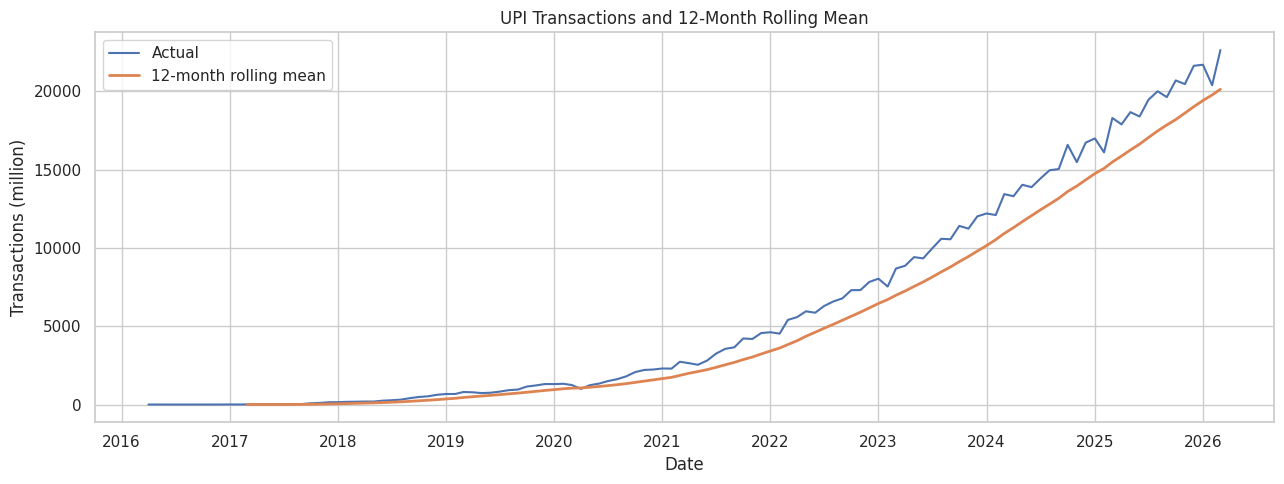

In [ ]:
volume = df["UPI_Transactions_Mn"].dropna()

rolling_mean = volume.rolling(12).mean()
rolling_std = volume.rolling(12).std()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(volume.index, volume, label="Actual")
ax.plot(rolling_mean.index, rolling_mean, label="12-month rolling mean", linewidth=2)
ax.set_title("UPI Transactions and 12-Month Rolling Mean")
ax.set_xlabel("Date")
ax.set_ylabel("Transactions (million)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. STL decomposition

For monthly data we use `period=12`.

STL separates the series into:

\[
Y_t = T_t + S_t + R_t
\]

where `T` is trend, `S` is seasonal, and `R` is residual.

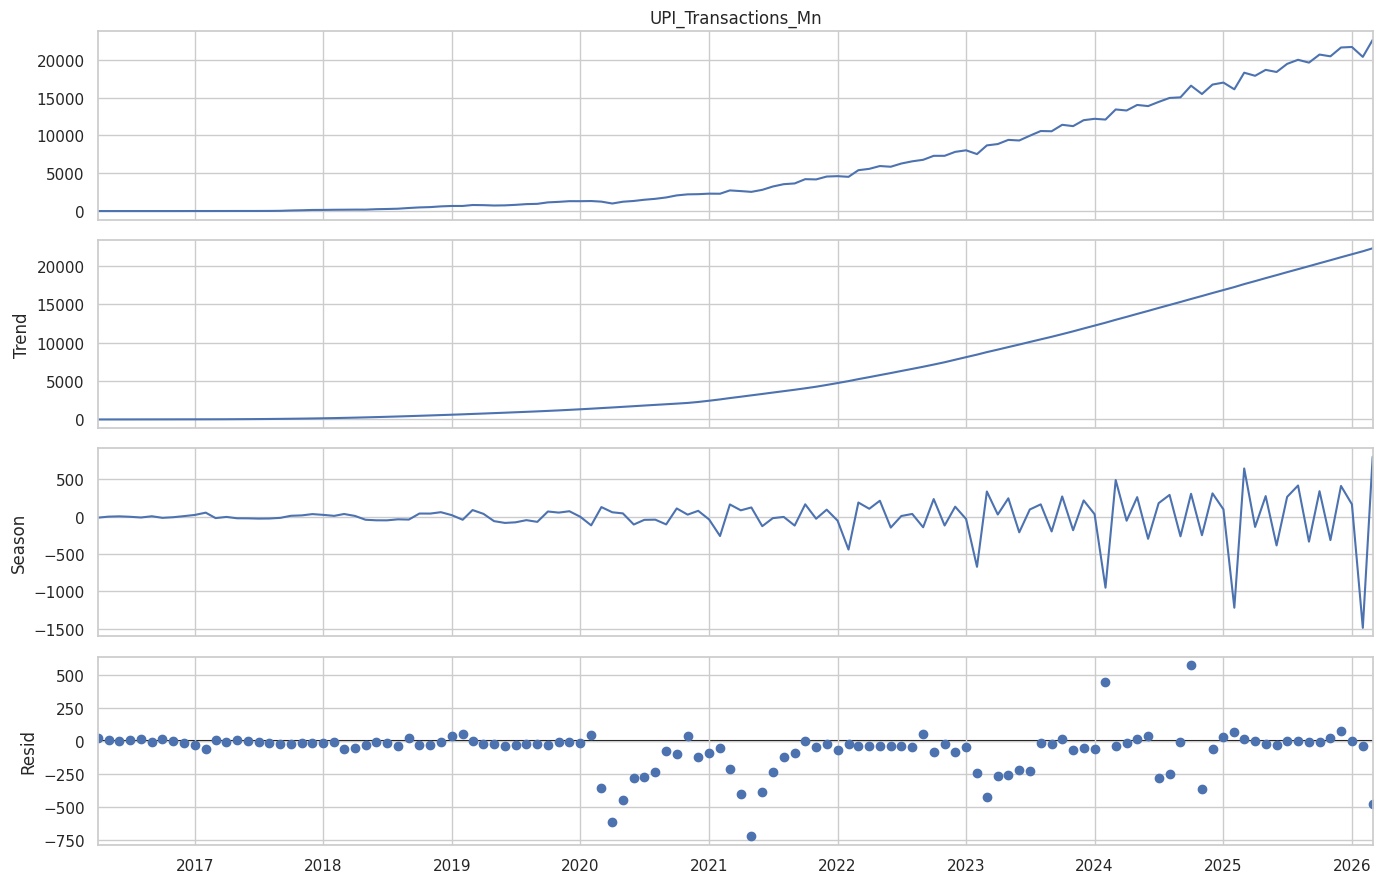

In [ ]:
stl = STL(volume, period=12, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(14, 9)
plt.tight_layout()
plt.show()

## 10. Stationarity check

The original UPI series has a strong upward trend. A log transformation helps stabilize the variance, but **a log transformation does not automatically remove a trend**. Therefore we check stationarity using both ADF and KPSS.


In [ ]:
def stationarity_report(series, name, adf_regression="c"):
    s = series.dropna()
    adf_result = adfuller(s, regression=adf_regression, autolag="AIC")
    print(f"\n{name}")
    print(f"ADF statistic : {adf_result[0]:.4f}")
    print(f"ADF p-value  : {adf_result[1]:.6f}")
    print(f"ADF lags     : {adf_result[2]}")
    print(f"ADF result   : {'Stationary evidence' if adf_result[1] < 0.05 else 'Non-stationary evidence'}")
    kpss_result = kpss(s, regression="c", nlags="auto")
    print(f"KPSS statistic: {kpss_result[0]:.4f}")
    print(f"KPSS p-value  : {kpss_result[1]:.6f}")
    print(f"KPSS result   : {'Stationary evidence' if kpss_result[1] > 0.05 else 'Non-stationary evidence'}")

stationarity_report(volume, "Original UPI transaction volume", adf_regression="c")



Original UPI transaction volume
ADF statistic : -1.7050
ADF p-value  : 0.428526
ADF lags     : 13
ADF result   : Non-stationary evidence
KPSS statistic: 1.6106
KPSS p-value  : 0.010000
KPSS result   : Non-stationary evidence


/tmp/ipykernel_7424/1385705302.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_result = kpss(s, regression="c", nlags="auto")


The log transformation is used to reduce the increasing variance. We **do not assume** that logging removes the trend. For the log series, the ADF test includes a deterministic trend (`regression="ct"`) because the plot still shows an upward movement. KPSS is also used as a cross-check.


## 11. Log transformation

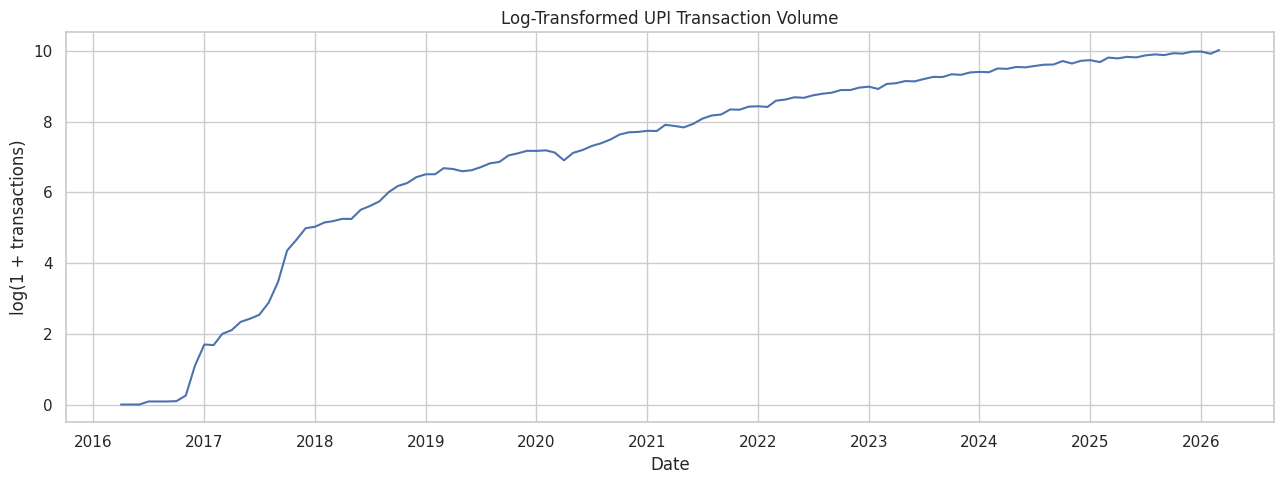


Log-transformed volume
ADF statistic : -4.6539
ADF p-value  : 0.000836
ADF lags     : 11
ADF result   : Stationary evidence
KPSS statistic: 1.5531
KPSS p-value  : 0.010000
KPSS result   : Non-stationary evidence


/tmp/ipykernel_7424/1385705302.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_result = kpss(s, regression="c", nlags="auto")


In [ ]:
log_volume = np.log1p(volume)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(log_volume.index, log_volume)
ax.set_title("Log-Transformed UPI Transaction Volume")
ax.set_xlabel("Date")
ax.set_ylabel("log(1 + transactions)")
plt.tight_layout()
plt.show()

stationarity_report(log_volume, "Log-transformed volume", adf_regression="ct")


## 12. Make the series stationary
For forecasting, we use **first differences of the log series** to remove the remaining growth/trend. Because the data are monthly and STL shows yearly seasonality, we also use a **12-month seasonal difference**. The resulting series is used for ACF/PACF and is checked again with ADF and KPSS.

Mathematically:

- Regular difference: `Δlog(Y_t) = log(Y_t) - log(Y_{t-1})`
- Seasonal difference: `Δ12 log(Y_t) = log(Y_t) - log(Y_{t-12})`


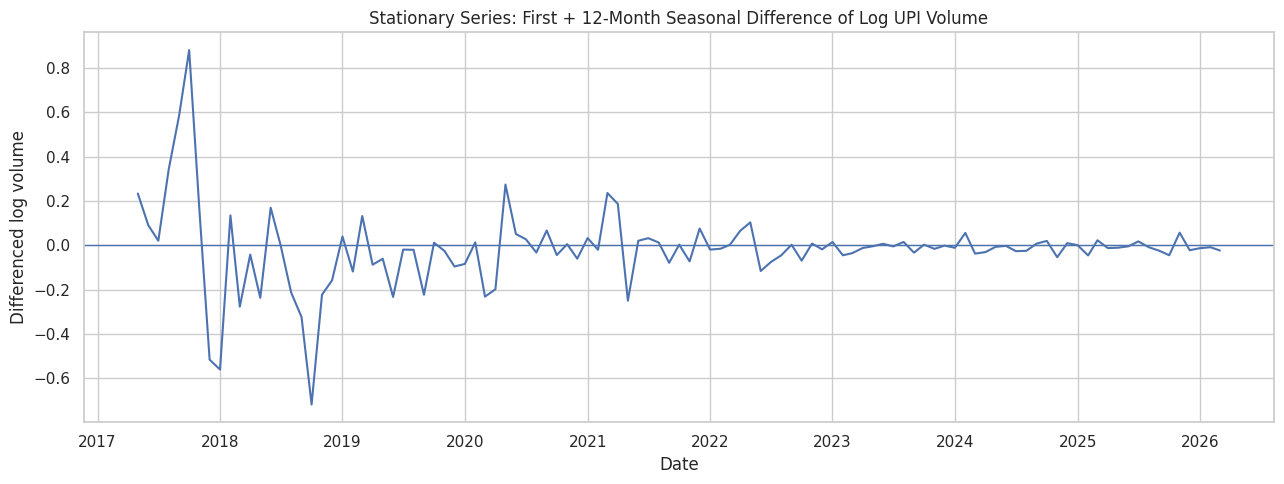


First difference of log volume
ADF statistic : -1.7396
ADF p-value  : 0.410845
ADF lags     : 10
ADF result   : Non-stationary evidence
KPSS statistic: 0.9271
KPSS p-value  : 0.010000
KPSS result   : Non-stationary evidence

Regular + seasonal difference of log volume
ADF statistic : -3.7489
ADF p-value  : 0.003475
ADF lags     : 11
ADF result   : Stationary evidence
KPSS statistic: 0.0845
KPSS p-value  : 0.100000
KPSS result   : Stationary evidence


/tmp/ipykernel_7424/1385705302.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_result = kpss(s, regression="c", nlags="auto")
/tmp/ipykernel_7424/1385705302.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_result = kpss(s, regression="c", nlags="auto")


In [ ]:
diff_log_volume = log_volume.diff()
stationary_volume = diff_log_volume.diff(12).dropna()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(stationary_volume.index, stationary_volume)
ax.axhline(0, linewidth=1)
ax.set_title("Stationary Series: First + 12-Month Seasonal Difference of Log UPI Volume")
ax.set_xlabel("Date")
ax.set_ylabel("Differenced log volume")
plt.tight_layout()
plt.show()

stationarity_report(diff_log_volume, "First difference of log volume", adf_regression="c")
stationarity_report(stationary_volume, "Regular + seasonal difference of log volume", adf_regression="c")


## 13. ACF and PACF

ACF and PACF are calculated on the **stationary transformed series**, not on the original trending data.

- ACF helps identify moving-average (MA) behaviour and remaining dependence.
- PACF helps identify autoregressive (AR) behaviour.
- Significant spikes at seasonal lags such as 12 support seasonal AR/MA terms.


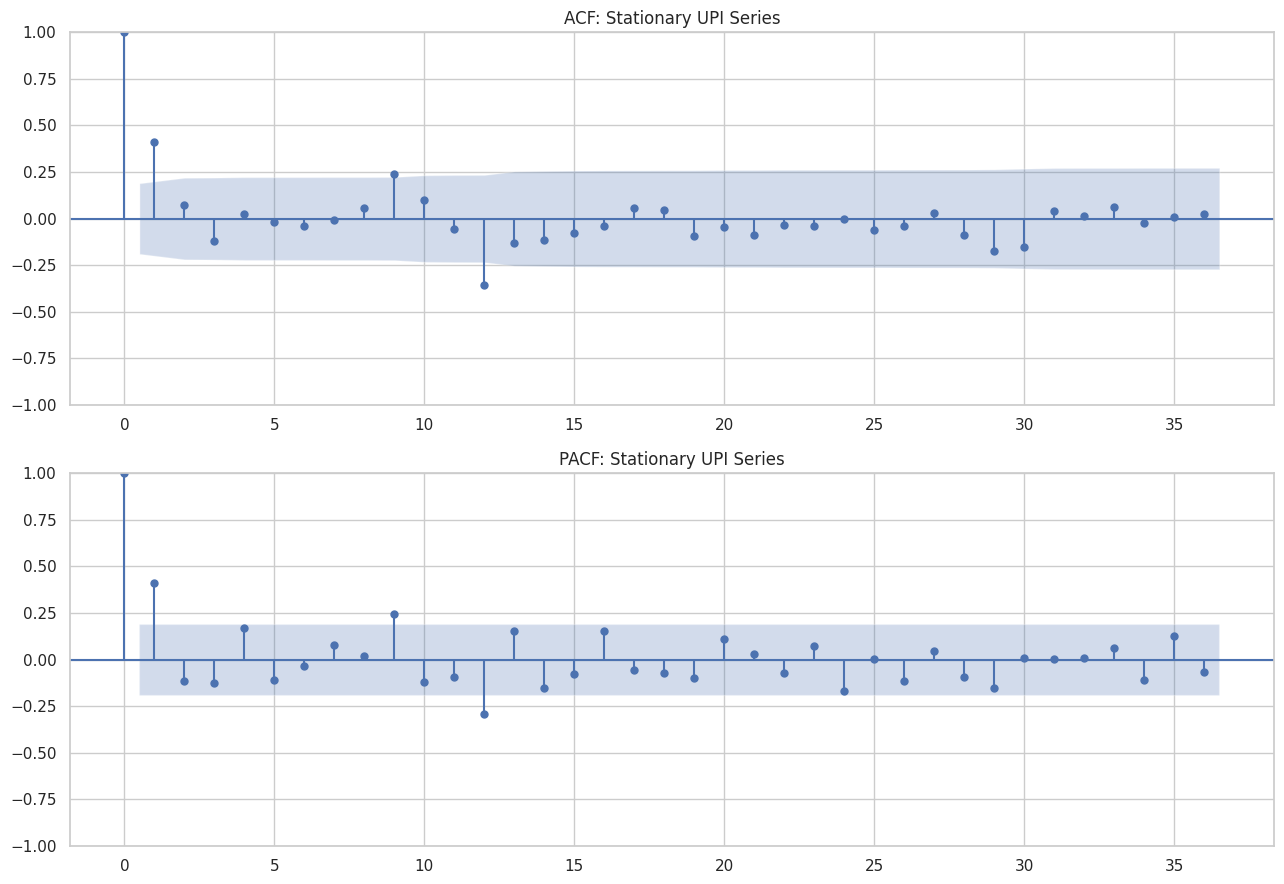

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

plot_acf(stationary_volume, lags=36, ax=axes[0])
axes[0].set_title("ACF: Stationary UPI Series")

plot_pacf(stationary_volume, lags=36, ax=axes[1], method="ywm")
axes[1].set_title("PACF: Stationary UPI Series")

plt.tight_layout()
plt.show()


### How ACF and PACF guide the models

- **PACF at short lags:** significant short-lag spikes support an AR component.
- **ACF at short lags:** significant short-lag spikes support an MA component.
- **Seasonal lags:** spikes around 12. indicate annual dependence in monthly data and motivate seasonal terms.
- These plots provide **candidate orders**; the final choice should also be checked using holdout errors and residual diagnostics.

Because the stationary transformation uses one regular difference and one seasonal difference, the SARIMA model uses **d=1 and D=1**.


## 14. Time-based train/test split

The final 12 months are reserved for testing.

This is essential for forecasting: the model must not train on future observations.

In [ ]:
target = df["UPI_Transactions_Mn"].dropna()

TEST_SIZE = 12

train = target.iloc[:-TEST_SIZE]
test = target.iloc[-TEST_SIZE:]

print("Training:", train.index.min().date(), "to", train.index.max().date())
print("Testing :", test.index.min().date(), "to", test.index.max().date())
print("Train size:", len(train))
print("Test size :", len(test))

Training: 2016-04-01 to 2025-03-01
Testing : 2025-04-01 to 2026-03-01
Train size: 108
Test size : 12


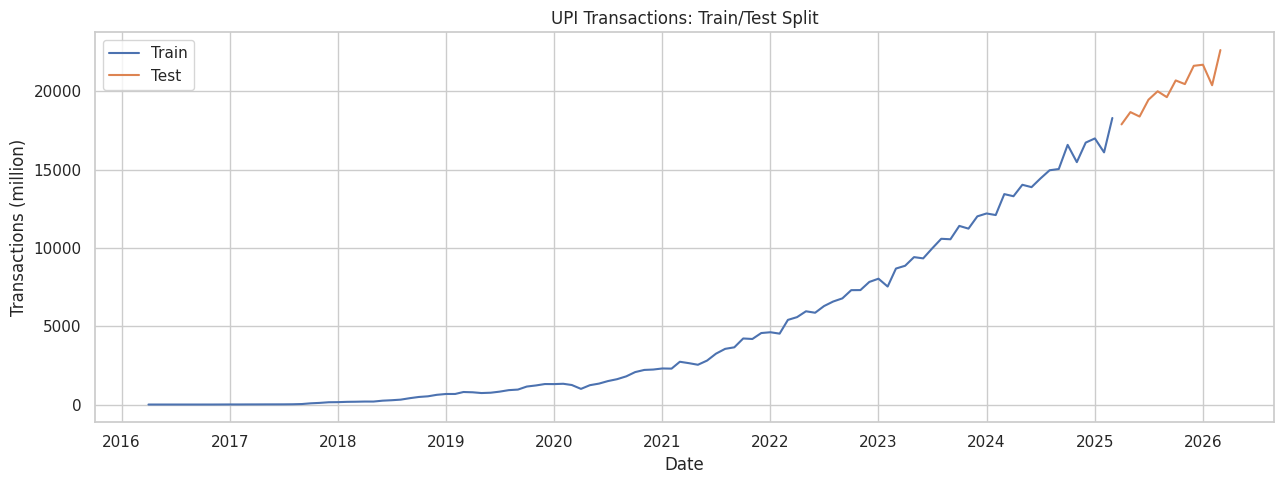

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index, train, label="Train")
ax.plot(test.index, test, label="Test")
ax.set_title("UPI Transactions: Train/Test Split")
ax.set_xlabel("Date")
ax.set_ylabel("Transactions (million)")
ax.legend()
plt.tight_layout()
plt.show()

## 15. Forecast evaluation metrics

In [ ]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = np.abs(y_true) + np.abs(y_pred)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / denominator)

def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE (%)": mape(y_true, y_pred),
        "sMAPE (%)": smape(y_true, y_pred)
    }

results = []

## 18. Holt-Winters Exponential Smoothing

In [ ]:
ets_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
)

ets_fit = ets_model.fit(optimized=True)
ets_pred = ets_fit.forecast(TEST_SIZE)

results.append(
    evaluate_model("Holt-Winters ETS", test, ets_pred)
)

## 19. ARIMA

We model the log-transformed series using **ARIMA(1,1,1)**.

- `p=1`: short-term AR behaviour suggested by PACF.
- `d=1`: first difference removes the remaining growth/trend.
- `q=1`: short-term MA behaviour suggested by ACF.

This is a candidate specification and is evaluated on the 12-month holdout set.


In [ ]:
log_train = np.log1p(train)

arima_model = SARIMAX(
    log_train,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

arima_fit = arima_model.fit(disp=False)
arima_log_pred = arima_fit.get_forecast(steps=TEST_SIZE).predicted_mean
arima_pred = np.expm1(arima_log_pred)
arima_pred.index = test.index
results.append(evaluate_model("ARIMA(1,1,1)", test, arima_pred))


## 20. SARIMA

Monthly UPI data have a 12-month seasonal cycle. We therefore use:

**SARIMA(1,1,1)(1,1,1,12)**

- `d=1`: regular differencing removes the remaining trend.
- `D=1`: seasonal differencing removes the annual seasonal level pattern.
- `p=1, q=1`: candidate short-term AR/MA terms from PACF/ACF.
- `P=1, Q=1`: candidate seasonal AR/MA terms supported by seasonal autocorrelation.

The exact order is validated using holdout performance and residual diagnostics.


In [ ]:
sarima_model = SARIMAX(
    log_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
sarima_log_pred = sarima_fit.get_forecast(steps=TEST_SIZE).predicted_mean
sarima_pred = np.expm1(sarima_log_pred)
sarima_pred.index = test.index
results.append(evaluate_model("SARIMA(1,1,1)(1,1,1,12)", test, sarima_pred))


## 20. Compare forecasting models


In [ ]:
results_df = pd.DataFrame(results)
display(results_df.round(2))

,Model,MAE,RMSE,MAPE (%),sMAPE (%)
0,Holt-Winters ETS,249.54,310.81,1.22,1.23
1,"ARIMA(1,1,1)","1,982.46","2,068.39",9.92,9.41
2,"SARIMA(1,1,1)(1,1,1,12)","1,504.53","1,729.53",7.26,6.94


Compare the models using the 12-month holdout period and the error metrics. Focus on MAE, RMSE and MAPE.


## 22. Plot all forecasts against the actual test period

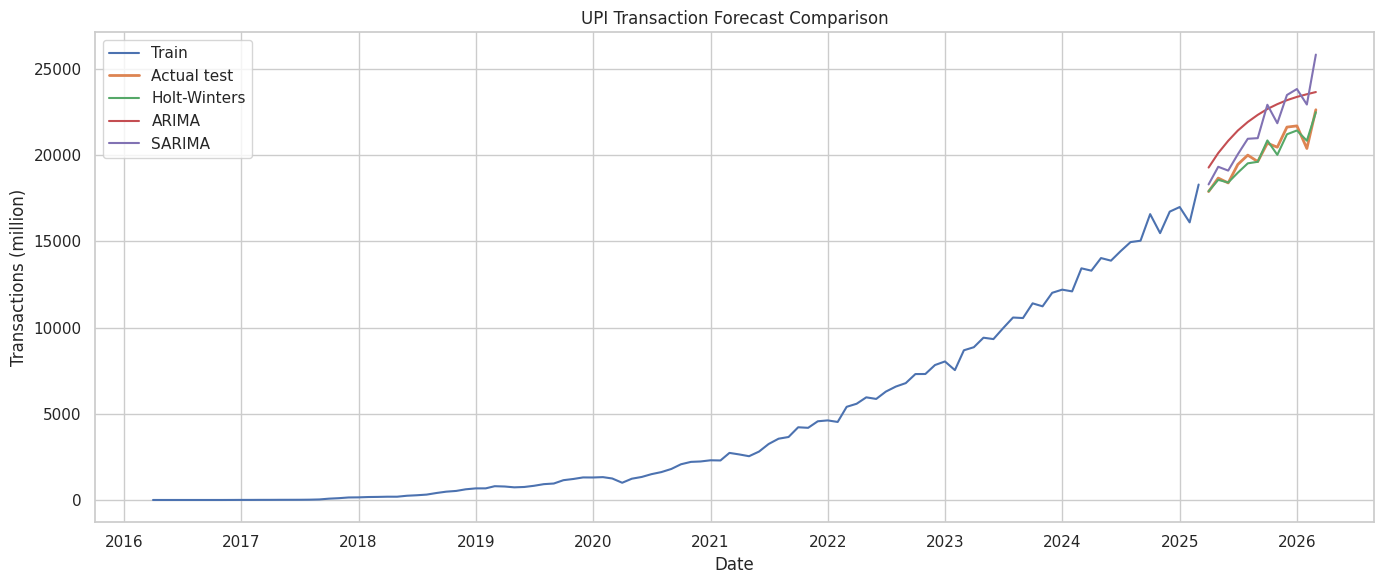

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train, label="Train")
ax.plot(test.index, test, label="Actual test", linewidth=2)

ax.plot(ets_pred.index, ets_pred, label="Holt-Winters")
ax.plot(arima_pred.index, arima_pred, label="ARIMA")
ax.plot(sarima_pred.index, sarima_pred, label="SARIMA")

ax.set_title("UPI Transaction Forecast Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Transactions (million)")
ax.legend()

plt.tight_layout()
plt.show()

## 22. SARIMA residual diagnostics


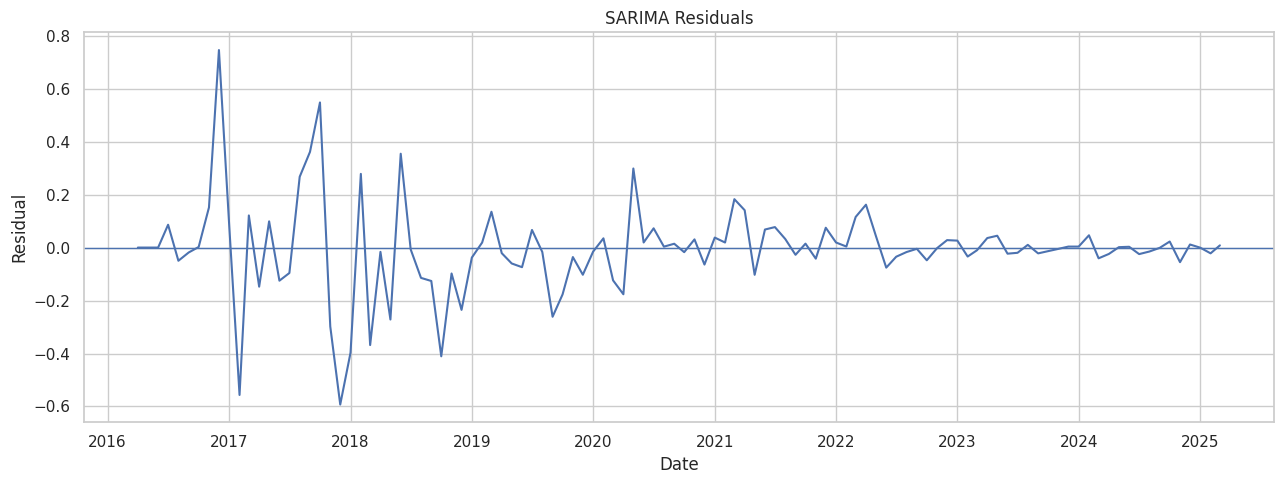

In [ ]:
sarima_residuals = sarima_fit.resid.dropna()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sarima_residuals)
ax.axhline(0, linewidth=1)
ax.set_title("SARIMA Residuals")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()

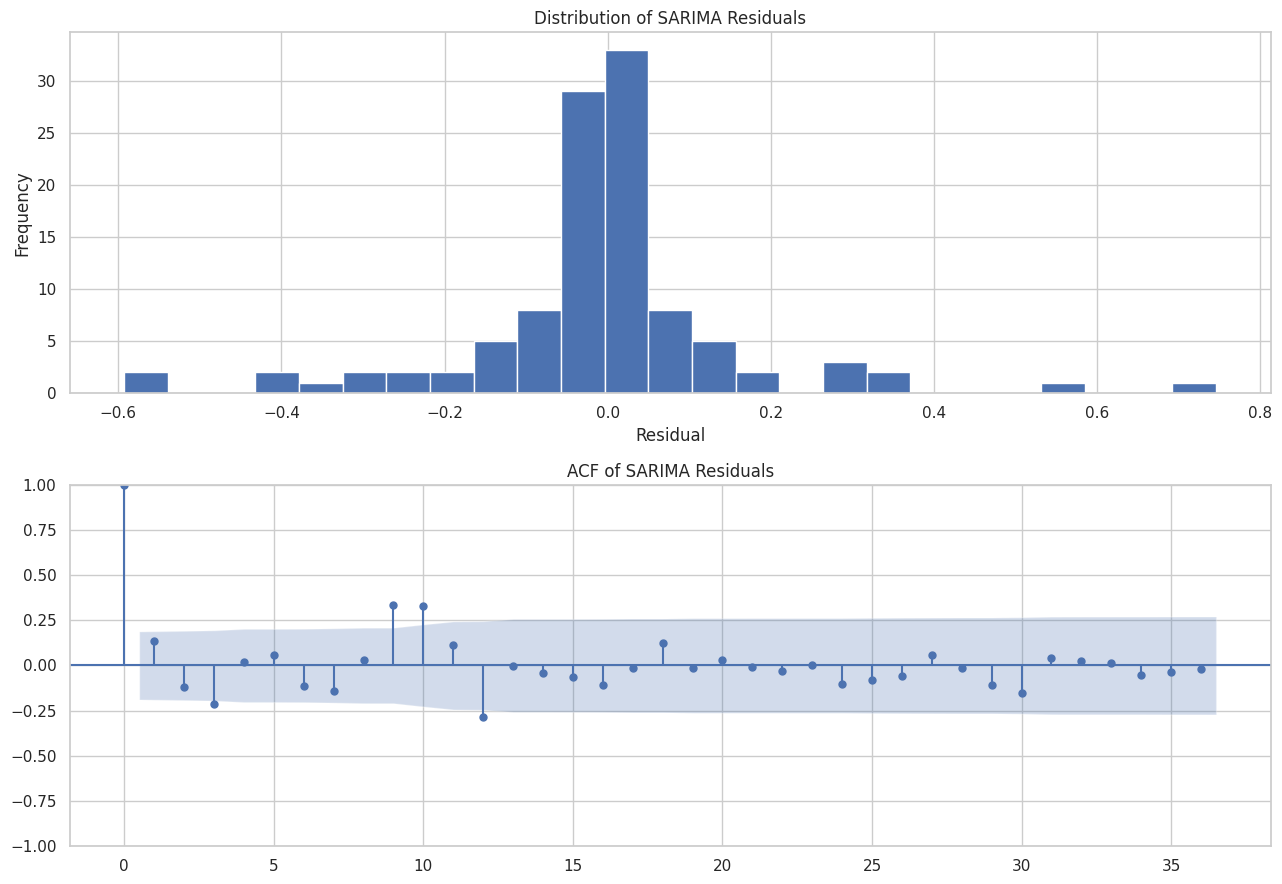

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

axes[0].hist(sarima_residuals, bins=25)
axes[0].set_title("Distribution of SARIMA Residuals")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Frequency")

plot_acf(sarima_residuals, lags=36, ax=axes[1])
axes[1].set_title("ACF of SARIMA Residuals")

plt.tight_layout()
plt.show()

## 24. Ljung-Box test

- **H0:** no autocorrelation up to the tested lag.
- Small p-value: evidence of remaining autocorrelation.
- Large p-value: insufficient evidence of remaining autocorrelation.

Use this together with the residual ACF.

In [ ]:
ljung_box = acorr_ljungbox(
    sarima_residuals,
    lags=[12, 24],
    return_df=True
)

display(ljung_box)

,lb_stat,lb_pvalue
12,51.68,0.00
24,57.92,0.00


## 25. Refit the candidate SARIMA on all available data

After holdout evaluation, refit the same **SARIMA(1,1,1)(1,1,1,12)** specification on the full log-transformed series.


In [ ]:
full_log = np.log1p(target)

final_model = SARIMAX(
    full_log,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit(disp=False)
FORECAST_HORIZON = 6
future_log = final_fit.get_forecast(steps=FORECAST_HORIZON).predicted_mean
future_forecast = np.expm1(future_log)
future_forecast.name = "Forecast_Transactions_Mn"
display(future_forecast.to_frame())


,Forecast_Transactions_Mn
2026-04-01,"22,328.03"
2026-05-01,"23,466.47"
2026-06-01,"23,204.95"
2026-07-01,"24,454.84"
2026-08-01,"25,293.25"
2026-09-01,"25,107.48"


## 25. Plot the six-month forecast


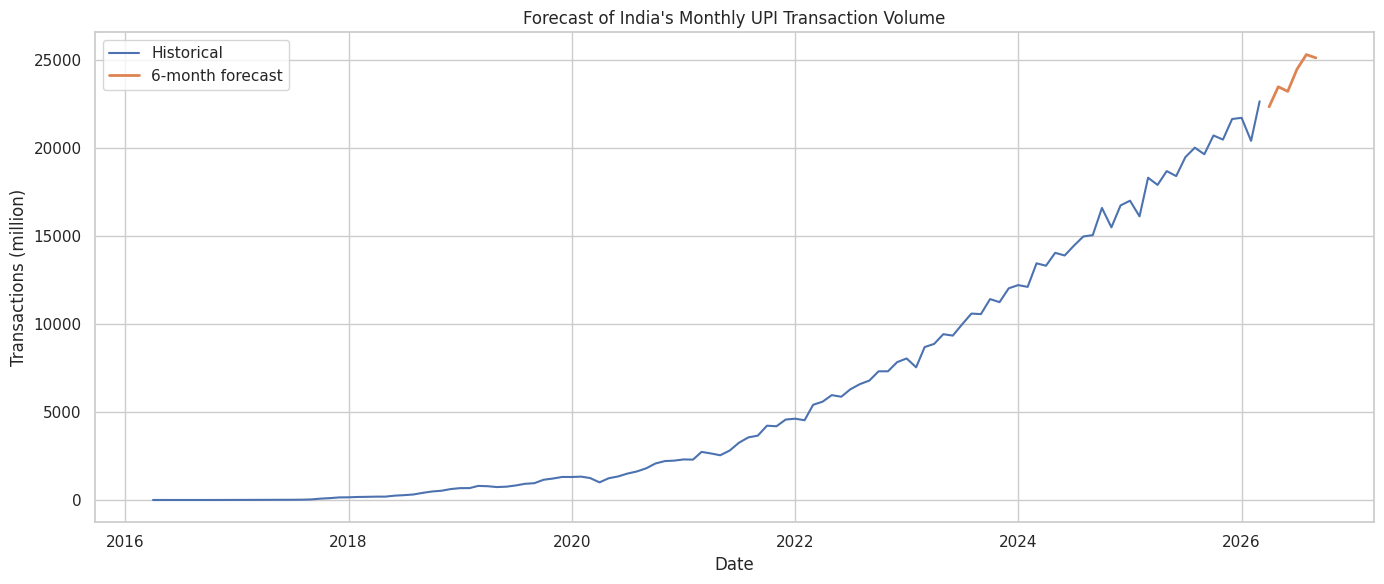

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(target.index, target, label="Historical")
ax.plot(
    future_forecast.index,
    future_forecast,
    label="6-month forecast",
    linewidth=2
)

ax.set_title("Forecast of India's Monthly UPI Transaction Volume")
ax.set_xlabel("Date")
ax.set_ylabel("Transactions (million)")
ax.legend()

plt.tight_layout()
plt.show()

## 26. Save the future forecast


In [ ]:
forecast_output = future_forecast.reset_index()
forecast_output.columns = ["Date", "Forecast_Transactions_Mn"]

forecast_output.to_csv(
    "upi_future_forecast.csv",
    index=False
)

display(forecast_output)
print("Saved: upi_future_forecast.csv")

,Date,Forecast_Transactions_Mn
0,2026-04-01,"22,328.03"
1,2026-05-01,"23,466.47"
2,2026-06-01,"23,204.95"
3,2026-07-01,"24,454.84"
4,2026-08-01,"25,293.25"
5,2026-09-01,"25,107.48"


Saved: upi_future_forecast.csv


# 27. Final project interpretation

Summary:

1. **Trend:** UPI transaction volume has strong long-term growth.
2. **Variance:** The log transformation reduces the increasing scale of fluctuations.
3. **Stationarity:** The original series is non-stationary. The log transformation alone should not be assumed to remove trend; regular and seasonal differencing are used and checked with ADF/KPSS.
4. **ACF/PACF:** These are interpreted on the stationary transformed series and used to propose AR/MA and seasonal terms.
5. **Forecast comparison:** Compare Holt-Winters, ARIMA and SARIMA using MAE, RMSE and MAPE on the 12-month holdout set.
6. **Diagnostics:** Use residual ACF and Ljung-Box to check for remaining autocorrelation.
7. **Forecast:** Refit the selected candidate SARIMA on all available history and produce the six-month forecast.

###

> I first checked the original UPI series and found strong trend. I used a log transformation to stabilize the variance, but I did not treat the log transformation as automatically making the series stationary. I checked stationarity with both ADF and KPSS. Because monthly UPI data also show yearly seasonality, I used one regular difference and one 12-month seasonal difference. I then examined ACF and PACF on this stationary series to identify candidate AR and MA terms. Finally, I compared Holt-Winters, ARIMA and SARIMA on a time-based 12-month test set and checked the residuals with ACF and Ljung-Box before producing the final forecast.
